In [1]:
from miditok import REMI

REMI().encode("datasets/Seperated-POP909-Dataset/mel/001.mid")


/opt/dlami/nvme/ugrip_yuanhsin/StreamMUSE/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[TokSequence(tokens=['Bar_None', 'Bar_None', 'Bar_None', 'Bar_None', 'Bar_None', 'Position_25', 'Pitch_61', 'Velocity_115', 'Duration_0.1.8', 'Position_27', 'Pitch_63', 'Velocity_111', 'Duration_0.1.8', 'Position_29', 'Pitch_66', 'Velocity_119', 'Duration_0.1.8', 'Position_31', 'Pitch_68', 'Velocity_111', 'Duration_0.1.8', 'Bar_None', 'Position_1', 'Pitch_70', 'Velocity_111', 'Duration_0.1.8', 'Position_5', 'Pitch_66', 'Velocity_111', 'Duration_0.2.8', 'Position_9', 'Pitch_63', 'Velocity_119', 'Duration_0.3.8', 'Position_13', 'Pitch_68', 'Velocity_115', 'Duration_1.4.8', 'Bar_None', 'Position_1', 'Pitch_68', 'Velocity_111', 'Duration_0.3.8', 'Position_5', 'Pitch_65', 'Velocity_115', 'Duration_0.2.8', 'Position_9', 'Pitch_61', 'Velocity_115', 'Duration_0.2.8', 'Position_13', 'Pitch_66', 'Velocity_119', 'Duration_1.1.8', 'Position_25', 'Pitch_61', 'Velocity_111', 'Duration_0.1.8', 'Position_27', 'Pitch_63', 'Velocity_111', 'Duration_0.1.8', 'Position_29', 'Pitch_66', 'Velocity_115', 'Dur

In [1]:
from miditok import REMI, TokenizerConfig

print(REMI().special_tokens_ids)
print(REMI().special_tokens)
print([token for i, token in enumerate(REMI().vocab.items()) if token[0].startswith("D")])
print(REMI().time_signatures)
print(REMI()._time_token_to_ticks((10, 2, 8), REMI().time_division))
print(REMI().vocab.get("Bar_None"))
print(REMI().vocab_size)

/opt/dlami/nvme/ugrip_yuanhsin/StreamMUSE/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[0, 1, 2, 3]
['PAD_None', 'BOS_None', 'EOS_None', 'MASK_None']
[('Duration_0.1.8', 125), ('Duration_0.2.8', 126), ('Duration_0.3.8', 127), ('Duration_0.4.8', 128), ('Duration_0.5.8', 129), ('Duration_0.6.8', 130), ('Duration_0.7.8', 131), ('Duration_1.0.8', 132), ('Duration_1.1.8', 133), ('Duration_1.2.8', 134), ('Duration_1.3.8', 135), ('Duration_1.4.8', 136), ('Duration_1.5.8', 137), ('Duration_1.6.8', 138), ('Duration_1.7.8', 139), ('Duration_2.0.8', 140), ('Duration_2.1.8', 141), ('Duration_2.2.8', 142), ('Duration_2.3.8', 143), ('Duration_2.4.8', 144), ('Duration_2.5.8', 145), ('Duration_2.6.8', 146), ('Duration_2.7.8', 147), ('Duration_3.0.8', 148), ('Duration_3.1.8', 149), ('Duration_3.2.8', 150), ('Duration_3.3.8', 151), ('Duration_3.4.8', 152), ('Duration_3.5.8', 153), ('Duration_3.6.8', 154), ('Duration_3.7.8', 155), ('Duration_4.0.4', 156), ('Duration_4.1.4', 157), ('Duration_4.2.4', 158), ('Duration_4.3.4', 159), ('Duration_5.0.4', 160), ('Duration_5.1.4', 161), ('Duration_

In [3]:
from mido import MidiFile
import os


def inspect_midi(filepath):
    """检查并打印MIDI文件的基本信息，包括使用的乐器。"""
    try:
        mid = MidiFile(filepath)
        print(f"--- Inspecting: {filepath} ---")
        print(f"Type: {mid.type}")
        print(f"Ticks per beat: {mid.ticks_per_beat}")
        print(f"Number of tracks: {len(mid.tracks)}")
        for i, track in enumerate(mid.tracks):
            print(f"  Track {i}: '{track.name}' ({len(track)} messages)")

            # 查找并打印该轨道中所有使用的乐器 (program_change events)
            # 使用集合来自动去重
            instruments = {msg.program for msg in track if msg.type == "program_change"}
            if instruments:
                # 对乐器编号进行排序，方便查看
                print(f"    Instruments (Program #): {sorted(list(instruments))}")
            else:
                print("    Instruments (Program #): None found in this track")

        print("------------------------------------")
    except Exception as e:
        print(f"Could not inspect MIDI file {filepath}: {e}")


# 使用方法：
# 在您的主程序运行后，用这个函数检查一个输出文件
# 请确保文件路径是正确的
# if __name__ == "__main__": # 在Jupyter中，可以直接运行，无需此判断
OUTPUT_DIR = "datasets/Seperated-POP909-Dataset"
# 添加下面的代码来检查一个输出文件
# 请将 '001.mid' 替换为您输出目录中实际存在的文件名
example_acc_file = os.path.join(OUTPUT_DIR, "acc", "001.mid")
example_mel_file = os.path.join(OUTPUT_DIR, "mel", "001.mid")
if os.path.exists(example_acc_file):
    inspect_midi(example_acc_file)
if os.path.exists(example_mel_file):
    inspect_midi(example_mel_file)
else:
    # 修正了这里的打印信息，使其与检查的文件匹配
    print(f"Example file not found for inspection: {example_mel_file} or {example_acc_file}")


--- Inspecting: datasets/Seperated-POP909-Dataset/acc/001.mid ---
Type: 0
Ticks per beat: 480
Number of tracks: 1
  Track 0: 'BRIDGE' (2862 messages)
    Instruments (Program #): [0]
------------------------------------
--- Inspecting: datasets/Seperated-POP909-Dataset/mel/001.mid ---
Type: 0
Ticks per beat: 480
Number of tracks: 1
  Track 0: 'MELODY' (531 messages)
    Instruments (Program #): [0]
------------------------------------


In [5]:
import torch

val_step0 = torch.load("logs/REMI_RoFormer_pop909/val_step.pt")
print(val_step0.keys())
# print(val_step0["mel_data"].shape)
# print(val_step0["acc_data"].shape)
# print(val_step0["target"].view(27, 383, -1).shape)
# print(val_step0["preds"].view(27, 383, -1).argmax(-1)[0].shape)
print(val_step0["mel_data"][7])
print(val_step0["acc_data"][6])
print(val_step0["target"].view(27, 383, -1)[6])
print(val_step0["preds"].view(27, 383, -1).argmax(-1).unsqueeze(1)[0])

dict_keys(['mel_data', 'acc_data', 'preds', 'target'])
tensor([1, 4, 4, 4, 4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

-------- 总体统计 --------
平均每首歌 bar 数: 84.31
平均每首歌 token 总数: 4776.22
平均每首歌 token 方差: 19.68
总 bar 数: 76641
平均每 bar token 数: 56.65
最大 bar token 数: 448
最小 bar token 数: 0
bar token standard deviation: 24.61


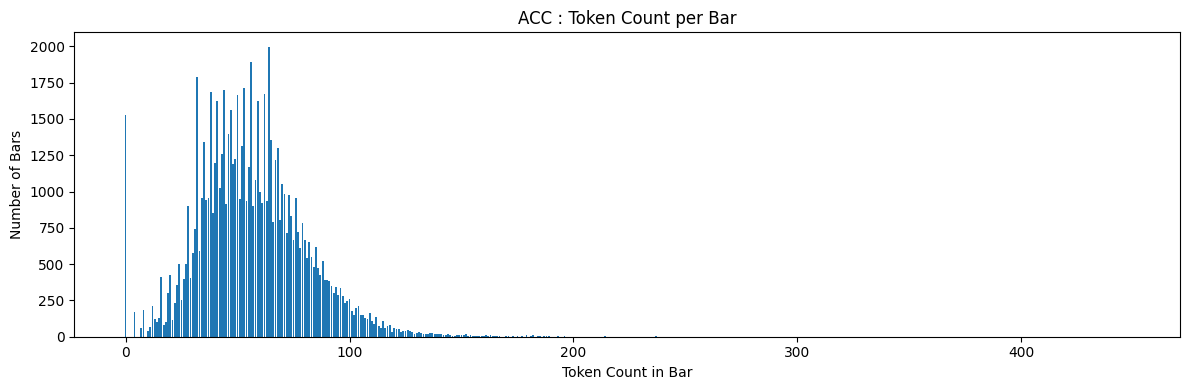

In [15]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
def count_bar_tokens(ids, bar_token=4):
    """统计每个 bar 的 token 数量"""
    bar_lengths = []
    current_bar_count = 0
    for token in ids:
        if token == bar_token:
            if current_bar_count >= 0:
                bar_lengths.append(current_bar_count)
            current_bar_count = 0
        else:
            current_bar_count += 1
    bar_lengths.append(current_bar_count)
    return bar_lengths

def plot_bar_lengths(bar_lengths, title="Bar Count for Each Token Number"):
    """绘制每种 token 数量的 bar 出现次数的分布图"""
    from collections import Counter
    import matplotlib.pyplot as plt
    import numpy as np
    count_dict = Counter(bar_lengths)
    xs = sorted(count_dict.keys())
    ys = [count_dict[x] for x in xs]

    plt.figure(figsize=(12, 4))
    plt.bar(xs, ys)
    plt.xlabel("Token Count in Bar")
    plt.ylabel("Number of Bars")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def process_folder(json_folder):
    """遍历文件夹，统计每首歌的 bar 数、token 总数、token 方差，并统计整体平均"""
    all_bar_lengths = []
    bar_counts = []
    token_counts = []
    token_stds = []
    for fname in os.listdir(json_folder):
        if fname.endswith(".json"):
            with open(os.path.join(json_folder, fname), "r") as f:
                data = json.load(f)
            ids = data["ids"][0]
            bar_lengths = count_bar_tokens(ids)
            all_bar_lengths.extend(bar_lengths)
            bar_counts.append(len(bar_lengths))
            token_counts.append(sum(bar_lengths))
            token_stds.append(np.std(bar_lengths))
            # print(f"{fname}: bar数={len(bar_lengths)}, token总数={sum(bar_lengths)}, token方差={np.std(bar_lengths):.2f}")
    print("-------- 总体统计 --------")
    print(f"平均每首歌 bar 数: {np.mean(bar_counts):.2f}")
    print(f"平均每首歌 token 总数: {np.mean(token_counts):.2f}")
    print(f"平均每首歌 token 方差: {np.mean(token_stds):.2f}")
    print(f"总 bar 数: {len(all_bar_lengths)}")
    print(f"平均每 bar token 数: {sum(all_bar_lengths)/len(all_bar_lengths):.2f}")
    print(f"最大 bar token 数: {max(all_bar_lengths)}")
    print(f"最小 bar token 数: {min(all_bar_lengths)}")
    print(f"bar token standard deviation: {np.std(all_bar_lengths):.2f}")
    plot_bar_lengths(all_bar_lengths, title="ACC : Token Count per Bar")

# 用法示例
json_folder = "datasets/Processed-POP909-Dataset-REMI/acc"
process_folder(json_folder)

In [4]:
import torch

torch.nonzero((torch.load("data/pop909_acc_cp10.pt") != 127))

tensor([[      0,       0],
        [      0,       1],
        [      0,       2],
        ...,
        [1148381,      27],
        [1148381,      28],
        [1148381,      29]])

In [3]:
import os
from collections import Counter
from miditok import REMI, MusicTokenizer
from tqdm.auto import tqdm


def analyze_midi_events_in_folder(folder_path: str, tokenizer: MusicTokenizer):
    """
    分析指定文件夹中所有 MIDI 文件，使用提供的 miditok 分词器进行解析，
    并统计每种事件类型的总数。

    :param folder_path: 包含 MIDI 文件的文件夹路径。
    :param tokenizer: 一个 miditok 分词器实例 (例如 REMI())。
    """
    if not os.path.isdir(folder_path):
        print(f"错误：找不到文件夹 {folder_path}")
        return

    total_event_counts = Counter()
    total_tokens_count = 0
    processed_files_count = 0

    # 查找所有 .mid 或 .midi 文件
    midi_files = [os.path.join(root, file) for root, _, files in os.walk(folder_path) for file in files if file.endswith((".mid", ".midi"))]

    if not midi_files:
        print(f"在 {folder_path} 中没有找到 MIDI 文件。")
        return

    print(f"找到 {len(midi_files)} 个 MIDI 文件。开始分析...")

    for file_path in tqdm(midi_files, desc="处理 MIDI 文件"):
        try:
            # 将 MIDI 文件转换为 token ID 列表 (每个轨道一个列表)
            ids_per_track = tokenizer.encode(file_path)

            # 将所有轨道的 token ID 合并到一个列表中
            all_ids = [token_id for track_ids in ids_per_track for token_id in track_ids]
            if not all_ids:
                continue

            # 将 token ID 转换回 token 字符串
            all_tokens = tokenizer._ids_to_tokens(all_ids)
            # print(all_tokens)
            # break
            # 从 token 字符串中提取事件类型（例如，从 'Note-On_60' 提取 'Note-On'）
            event_types = [str(token).split("_")[0] for token in all_tokens]

            total_tokens_count += len(all_tokens)
            processed_files_count += 1

            # 更新总计数器
            total_event_counts.update(event_types)

        except Exception as e:
            print(f"无法处理文件 {file_path}: {e}")

    print("\n--- 分析完成 ---")
    print(f"成功处理文件数: {processed_files_count}/{len(midi_files)}")
    print(f"事件 (Token) 总数: {total_tokens_count}")
    print("\n--- 各类型事件统计 ---")

    # 按数量从多到少打印
    for event_type, count in total_event_counts.most_common():
        percentage = (count / total_tokens_count) * 100 if total_tokens_count > 0 else 0
        print(f"- {event_type:<20} | 数量: {count:<10} | 占比: {percentage:.2f}%")


# --- 使用示例 ---
# 1. 初始化您想使用的分词器
#    这里的 REMI() 与您笔记本中其他部分使用的分词器一致。
tokenizer = REMI()

# 2. 指定要分析的文件夹路径
#    您可以将其更改为 "datasets/Seperated-POP909-Dataset/acc" 或其他任何包含MIDI文件的文件夹
folder_to_analyze_mel = "datasets/Seperated-POP909-Dataset/mel"
folder_to_analyze_acc = "datasets/Seperated-POP909-Dataset/acc"


# 3. 调用函数进行分析
print(f"========== 分析 Melodies ({folder_to_analyze_mel}) ==========")
analyze_midi_events_in_folder(folder_to_analyze_mel, tokenizer)

print(f"\n========== 分析 Accompaniments ({folder_to_analyze_acc}) ==========")
analyze_midi_events_in_folder(folder_to_analyze_acc, tokenizer)


========== 分析 Melodies (datasets/Seperated-POP909-Dataset/mel) ==========
找到 909 个 MIDI 文件。开始分析...


处理 MIDI 文件: 100%|██████████| 909/909 [00:05<00:00, 159.63it/s]



--- 分析完成 ---
成功处理文件数: 909/909
事件 (Token) 总数: 1307804

--- 各类型事件统计 ---
- Pitch                | 数量: 309423     | 占比: 23.66%
- Velocity             | 数量: 309423     | 占比: 23.66%
- Duration             | 数量: 309423     | 占比: 23.66%
- Position             | 数量: 308108     | 占比: 23.56%
- Bar                  | 数量: 71427      | 占比: 5.46%

========== 分析 Accompaniments (datasets/Seperated-POP909-Dataset/acc) ==========
找到 909 个 MIDI 文件。开始分析...


处理 MIDI 文件: 100%|██████████| 909/909 [00:19<00:00, 46.73it/s]


--- 分析完成 ---
成功处理文件数: 909/909
事件 (Token) 总数: 4417313

--- 各类型事件统计 ---
- Pitch                | 数量: 1224015    | 占比: 27.71%
- Velocity             | 数量: 1224015    | 占比: 27.71%
- Duration             | 数量: 1224015    | 占比: 27.71%
- Position             | 数量: 669536     | 占比: 15.16%
- Bar                  | 数量: 75732      | 占比: 1.71%


In [6]:
import miditok
tokens = miditok.REMI().encode("datasets/Seperated-POP909-Dataset/acc/001.mid")
# print(tokens)
decodes = miditok.REMI().decode(tokens)
print(decodes)

Score(ttype=Tick, tpq=8, begin=0, end=2327, tracks=1, notes=1292, time_sig=1, key_sig=0, markers=0)


In [3]:
import music21 as m21

midi_file_path = 'x.mid'

try:
    midi_score = m21.converter.parse(midi_file_path)
    print("MIDI file loaded successfully!")

    # Print a summary of the score
    print("\n--- Score Summary ---")
    print(f"Number of parts: {len(midi_score.parts)}")
    print(f"Tempo: {midi_score.duration.quarterLength}") # This is rough, check specific tempo objects
    for i, part in enumerate(midi_score.parts):
        print(f"Part {i+1} Name: {part.partName or 'Unnamed'}")
        print(f"  Number of notes/chords: {len(part.flat.notesAndRests)}")
        # Example: Print first 10 notes of a part
        for note in part.flat.notesAndRests[:10]:
            if note.isNote:
                print(f"    Note: {note.nameWithOctave}, Offset: {note.offset}, Duration: {note.duration.type}")
            elif note.isChord:
                print(f"    Chord: {note.pitches}, Offset: {note.offset}, Duration: {note.duration.type}")

except Exception as e:
    print(f"Error loading or processing MIDI file: {e}")

MIDI file loaded successfully!

--- Score Summary ---
Number of parts: 1
Tempo: 296.0
Part 1 Name: Piano
  Number of notes/chords: 529
    Note: E-5, Offset: 20.5, Duration: eighth
    Note: C#5, Offset: 21.0, Duration: eighth
    Note: E-5, Offset: 21.5, Duration: eighth
    Note: C#5, Offset: 22.0, Duration: eighth


In [4]:
import music21 as m21

midi_file_path = 'datasets/Seperated-POP909-Dataset/mel/002.mid'

try:
    midi_score = m21.converter.parse(midi_file_path)
    print("MIDI file loaded successfully!")

    # Print a summary of the score
    print("\n--- Score Summary ---")
    print(f"Number of parts: {len(midi_score.parts)}")
    print(f"Tempo: {midi_score.duration.quarterLength}") # This is rough, check specific tempo objects
    for i, part in enumerate(midi_score.parts):
        print(f"Part {i+1} Name: {part.partName or 'Unnamed'}")
        print(f"  Number of notes/chords: {len(part.flat.notesAndRests)}")
        # Example: Print first 10 notes of a part
        for note in part.flat.notesAndRests[:10]:
            if note.isNote:
                print(f"    Note: {note.nameWithOctave}, Offset: {note.offset}, Duration: {note.duration.type}")
            elif note.isChord:
                print(f"    Chord: {note.pitches}, Offset: {note.offset}, Duration: {note.duration.type}")

except Exception as e:
    print(f"Error loading or processing MIDI file: {e}")

MIDI file loaded successfully!

--- Score Summary ---
Number of parts: 1
Tempo: 228.0
Part 1 Name: MELODY
  Number of notes/chords: 520
    Note: E-5, Offset: 20.5, Duration: 16th
    Note: C#5, Offset: 20.75, Duration: 16th
    Note: E-5, Offset: 21.0, Duration: 16th
    Note: C#5, Offset: 21.25, Duration: 16th


In [22]:
import torch
    # x = [a0,m0,a5,m1,a6,m2...,a(n-1),m(n-5)]
    # y = [m0,a5,m1,a6,m2,a7...,m(n-5),a(n)]
n=17
frame_shift = 5
mel_data = torch.arange(1,n+frame_shift+1).view(1,-1,1)
acc_data = torch.arange(1,n+frame_shift+1).view(1,-1,1)
acc_data*=-1
assert mel_data.ndim == 3 and acc_data.ndim == 3, (
    f"mel_data and acc_data must be 3-dimensional tensors,but got mel_data:{mel_data.shape} acc_data:{acc_data.shape}"
)

x = torch.empty(
    mel_data.shape[0],
    mel_data.shape[1] + acc_data.shape[1] - 2*frame_shift,
    mel_data.shape[2],
    dtype=mel_data.dtype,
    device=mel_data.device,
)

y = torch.empty(
    mel_data.shape[0],
    mel_data.shape[1] + acc_data.shape[1] - 2* frame_shift,
    mel_data.shape[2],
    dtype=mel_data.dtype,
    device=mel_data.device,
)

x[:,0,:]=acc_data[:,0,:]
x[:,1::2,:]=mel_data[:,:-frame_shift,:]
x[:,2::2,:]=acc_data[:,frame_shift:-1,:]

y[:,0::2,:]=mel_data[:,:-frame_shift,:]
y[:,1::2,:]=acc_data[:,frame_shift:,:]
    
print(x.squeeze())
print(y.squeeze())
    

tensor([ -1,   1,  -6,   2,  -7,   3,  -8,   4,  -9,   5, -10,   6, -11,   7,
        -12,   8, -13,   9, -14,  10, -15,  11, -16,  12, -17,  13, -18,  14,
        -19,  15, -20,  16, -21,  17])
tensor([  1,  -6,   2,  -7,   3,  -8,   4,  -9,   5, -10,   6, -11,   7, -12,
          8, -13,   9, -14,  10, -15,  11, -16,  12, -17,  13, -18,  14, -19,
         15, -20,  16, -21,  17, -22])
